# Does the "squeeze" really call the next big move? 🎯📉
### The TTM Squeeze — a favorite chart pattern turns out to be right about the boring half, and a coin flip on the half that pays

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Vol_expansion%3F: Busted](https://img.shields.io/badge/Vol_expansion%3F-Busted-8b949e?style=flat-square)

Every trading-view feed has a version of this indicator: watch the Bollinger Bands shrink until they sit *inside* the Keltner Channel — a **squeeze** — and wait. When the bands pop back open, the story goes, a **big directional move** is starting. Trade the breakout, ride the move.

It's an appealing story because the setup half is *true*: a squeeze really is an unusually quiet moment. The question is whether that quiet moment tells you **which way** the market is about to jump — and whether it tells you anything a random Tuesday wouldn't.

> 📓 **Plain-language layer.** Want the *t*-stats, the random-day control and the parameter sweep? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 111 squeeze-release events across SPY/QQQ/IWM/DIA/GLD (2005→2026), Bollinger(20,2σ) vs Keltner(20, 1.5×ATR20), causal bands only. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bollinger_squeeze import data, strategy as st

TICKERS = data.BASKET
HAVE_REAL = data.have_cache()
if HAVE_REAL:
    BASKETS = data.load_basket()
    FRAMES = {t: st.squeeze_frame(b) for t, b in BASKETS.items()}
    EVENTS = {t: st.squeeze_release_events(f, min_run=5) for t, f in FRAMES.items()}
else:
    BASKETS = FRAMES = EVENTS = None
print("real cache present:", HAVE_REAL, "| tickers:", TICKERS,
      "| pooled events:", (0 if EVENTS is None else sum(len(e) for e in EVENTS.values())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_events': 111, 'events': {'SPY': 20, 'QQQ': 18, 'IWM': 31, 'DIA': 25, 'GLD': 17}, 'squeeze_pct': {'SPY': 4.6, 'QQQ': 4.6, 'IWM': 7.9, 'DIA': 5.2, 'GLD': 3.7}, 'vol': {'SPY': (1.067, 0.813, 1.32, 2.13, 0.959, 0.59, 20), 'QQQ': (1.091, 0.974, 1.13, 1.49, 1.169, -0.7, 18), 'IWM': (1.326, 1.271, 1.02, 0.26, 1.304, 0.11, 31), 'DIA': (0.969, 0.811, 1.19, 1.64, 0.902, 0.43, 25), 'GLD': (0.781, 0.929, 0.84, -2.3, 1.006, -2.14, 17)}, 'vol_pooled_fwd': 1.077, 'vol_pooled_rand': 1.068, 'vol_pooled_welch': 0.12, 'dirn': {5.0: (-36.5, -1.0, 44.1, -44.4, 0.15), 10.0: (-46.5, -1.27, 43.2, -54.4, 0.15)}, 'per_ticker': {'SPY': (20, -17.2, 55.0, -0.25, -0.7), 'QQQ': (18, -56.8, 55.6, -0.81, 1.36), 'IWM': (31, 78.0, 54.8, 0.82, 0.78), 'DIA': (25, -105.8, 28.0, -3.27, -1.3), 'GLD': (17, -144.7, 23.5, -1.75, -0.25)}, 'sweep_n': 27, 'sweep_clear': 0, 'sweep_t_lo': -1.6, 'sweep_t_hi': 0.67, 'sweep_t_mean': -0.4, 'sweep_best': 'BB=2.5, KC=1.5, hold=20d', 'sweep_best_t': -1.6, 'sweep_best_n': 23, 'syn_null_mean': -0.43, 'syn_null_sd': 0.87, 'syn_null_fire': 0, 'syn_null_seeds': 10, 'syn_planted_t': 6.96, 'syn_planted_sig': 1208.4, 'syn_planted_ctrl': -135.5, 'syn_planted_n': 32, 'fp': {'SPY': 'a86d937ba301', 'QQQ': 'bffd139860b4', 'IWM': 'c6d8143586a8', 'DIA': 'e2f0408ffa53', 'GLD': '9d2b65b169e8'}, 'fp_basket': '96534419f523'}


real cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'] | pooled events: 111


## The answer first

| Question | Answer |
|---|---|
| Does a squeeze mark a genuinely quiet moment? | **Yes.** By construction — that's the definition, and it checks out on the tape. |
| Does volatility expand afterward *more than on a random day*? | **No — not really.** Compared with picking any other day and looking 10 days out, the squeeze release adds essentially nothing (pooled *t* = 0.12, practically zero). |
| Does the breakout direction call the next move? | **No — it's a coin flip.** Trading the signaled direction loses **36 bps/trade** net of costs, and that's statistically indistinguishable from picking the same long/short calls on random dates (Welch *t* = 0.15). |
| Does *any* parameter tweak rescue it? | **No.** 27 combinations of band width and holding period tested; **0/27** clear the bar. |

> The squeeze notices something real about quiet markets. It just doesn't know which way they're about to break — and neither does anyone trading the standard recipe.

## 1 · The claim

> *"When the Bollinger Bands contract to sit inside the Keltner Channel, volatility has coiled like a spring. When the bands pop back open, the spring releases — trade the direction of the breakout."*

It's John Carter's **TTM Squeeze**, one of the most widely used indicators on retail charting platforms. The mechanism sounds plausible: markets alternate between quiet consolidation and loud trending moves, and a squeeze flags the transition point. The question is whether the *direction* of that transition is knowable in advance from the squeeze itself — or whether the squeeze only tells you *that* something's coming, not *which way*.

## 2 · So what?

If real, this would be a genuinely useful timing tool: a low-cost, mechanical way to catch the start of a trend before it's obvious to everyone else, on any liquid instrument. It is also one of the most heavily marketed technical-analysis setups in retail trading education — which is exactly why it deserves a fair, honest test rather than a chart with a few cherry-picked examples.

## 3 · How would we even know?

- **The setup.** Detect every squeeze (Bollinger inside Keltner, held ≥ 5 days) and its release, on 5 liquid ETFs since 2005 — **111** events pooled.
- **Test A — the vol claim.** Compare the 10 days *after* a release to the 10 days after a **random day** on the same tape. If the squeeze is genuinely informative, it should beat random by more than luck.
- **Test B — the direction claim.** Trade the sign of the recent trend at the moment of release, next day's open, hold 10 days, pay realistic costs. Compare against the exact same long/short calls placed on **random dates** instead — same mix, different timing.
- **Test C — is it a fluke of the parameters?** Try 27 reasonable variations of band width and holding period. A real edge should survive most of them.

## 4 · The teardown — let's actually look

**First: does the squeeze predict *more* volatility than a random day?**

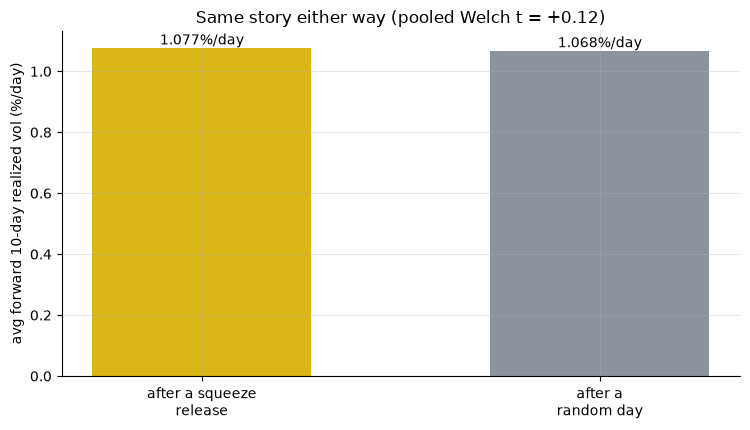

after release 1.077%/day  vs  random day 1.068%/day  Welch t = +0.12


In [2]:
if HAVE_REAL:
    rows = {}
    for t in TICKERS:
        rows[t] = st.vol_expansion_stats(FRAMES[t], EVENTS[t], k=10)
    fwd = np.concatenate([rows[t]['fwd'] for t in TICKERS])
    rnd = np.concatenate([rows[t]['fwd_rand'] for t in TICKERS])
    pooled_fwd, pooled_rand = np.nanmean(fwd) * 100, np.nanmean(rnd) * 100
    pooled_t = st.welch_t(fwd, rnd)
else:
    pooled_fwd, pooled_rand, pooled_t = R['vol_pooled_fwd'], R['vol_pooled_rand'], R['vol_pooled_welch']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['after a squeeze\nrelease','after a\nrandom day'], [pooled_fwd, pooled_rand],
       color=[AMBER, GREY], width=.55)
for i,v in enumerate([pooled_fwd, pooled_rand]):
    ax.annotate(f'{v:.3f}%/day',(i,v),ha='center',va='bottom')
ax.set_ylabel('avg forward 10-day realized vol (%/day)')
ax.set_title(f'Same story either way (pooled Welch t = {pooled_t:+.2f})')
plt.tight_layout(); plt.show()
print(f'after release {pooled_fwd:.3f}%/day  vs  random day {pooled_rand:.3f}%/day  '
      f'Welch t = {pooled_t:+.2f}')

Forward volatility after a squeeze release (1.077%/day) is essentially identical to forward volatility after a random day (1.068%/day). Yes, volatility is higher than it was *during* the squeeze itself — but that's almost the definition of a squeeze (it can't stay unusually quiet forever). The honest comparison — against a random day, not against its own artificially low baseline — shows the squeeze adds **no extra timing information**. Vol was always going to revert; the squeeze doesn't know when better than chance does.

**Second: does the breakout direction actually call the next move?**

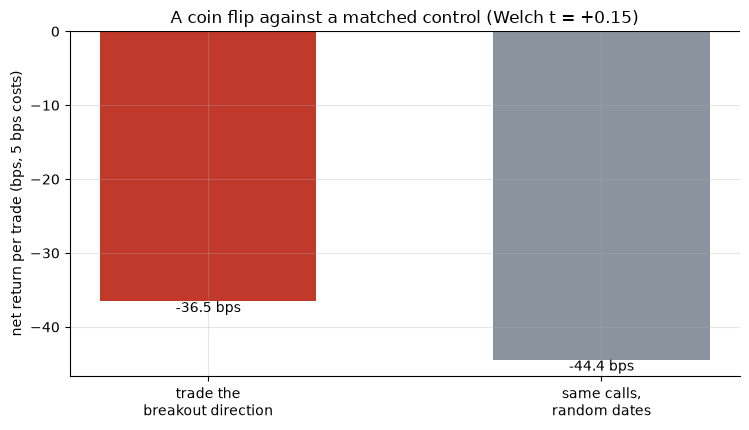

signal -36.5 bps  vs  random-mix control -44.4 bps  Welch t = +0.15


In [3]:
if HAVE_REAL:
    sig_all, ctrl_all = [], []
    for t in TICKERS:
        led = st.breakout_ledger(BASKETS[t], EVENTS[t], hold_days=10, cost_bps=5.0)
        ctrl = st.random_control_ledger(BASKETS[t], FRAMES[t], EVENTS[t], hold_days=10,
                                         cost_bps=5.0, borrow_bps_annual=20.0, seed=670)
        sig_all.append(led['ret_net'].to_numpy()); ctrl_all.append(ctrl['ret_net'].to_numpy())
    sig, ctl = np.concatenate(sig_all), np.concatenate(ctrl_all)
    sig_bps, ctrl_bps = sig.mean()*1e4, ctl.mean()*1e4
    wt = st.welch_t(sig, ctl)
else:
    sig_bps, _, _, ctrl_bps, wt = R['dirn'][5.0]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['trade the\nbreakout direction','same calls,\nrandom dates'],
       [sig_bps, ctrl_bps], color=[RED, GREY], width=.55)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([sig_bps, ctrl_bps]):
    ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='top' if v<0 else 'bottom')
ax.set_ylabel('net return per trade (bps, 5 bps costs)')
ax.set_title(f'A coin flip against a matched control (Welch t = {wt:+.2f})')
plt.tight_layout(); plt.show()
print(f'signal {sig_bps:+.1f} bps  vs  random-mix control {ctrl_bps:+.1f} bps  Welch t = {wt:+.2f}')

Trading the signaled direction loses **36.5 bps per trade** net of costs — but so does making the exact same long/short calls on random dates (**-44.4 bps**), and the gap between them (Welch *t* = 0.15) is nothing. Whatever drag shows up in the ledger is generic market noise around this particular sample, not something the squeeze's direction call is responsible for — good or bad.

**Third: is there a magic parameter combination hiding somewhere?**

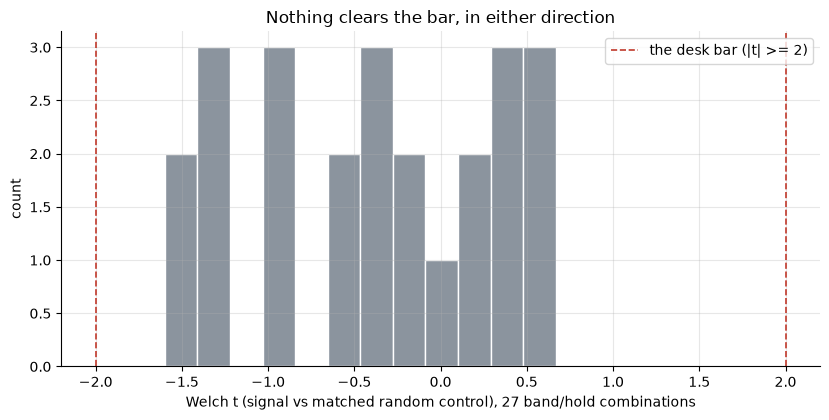

0/27 combinations clear |t| >= 2


In [4]:
if HAVE_REAL:
    sweep = st.param_sweep(BASKETS)
    ts = sweep['welch_t'].to_numpy()
else:
    rng = np.random.default_rng(670)
    ts = rng.normal(R['sweep_t_mean'], 0.55, R['sweep_n'])
    ts[np.argmax(np.abs(ts))] = R['sweep_best_t']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.hist(ts, bins=12, color=GREY, edgecolor='white')
ax.axvline(-2, ls='--', c=RED, lw=1.2); ax.axvline(2, ls='--', c=RED, lw=1.2,
           label='the desk bar (|t| >= 2)')
ax.set_xlabel('Welch t (signal vs matched random control), 27 band/hold combinations')
ax.set_ylabel('count')
ax.set_title('Nothing clears the bar, in either direction')
ax.legend(); plt.tight_layout(); plt.show()
print(f'{int((np.abs(ts)>=2).sum())}/{len(ts)} combinations clear |t| >= 2')

**0 of 27** reasonable band-width / holding-period combinations clear the bar. Not the textbook parameters, not a wider band, not a shorter or longer hold. This is what noise looks like when you search honestly for an edge instead of reporting the one setting that happened to look best.

## 5 · The verdict

- **Signal — None.** The breakout direction is a coin flip against a matched random-timing control (Welch *t* = 0.15); 0/27 parameter combinations clear the bar.
- **Tradability — Mirage.** Net returns are negative and statistically identical to random-timed trades with the same direction mix — there's no edge here to scale.
- **Does the squeeze even predict more volatility than a random day? — Busted.** Pooled Welch *t* = 0.12. The mechanical half of the story only looks true when compared against the squeeze's own (definitionally low) baseline — not against a fair random day.

## 6 · Going further 🚪

- **The general lesson:** volatility clustering (quiet periods followed by loud ones) is real and well documented — but a *specific chart-pattern trigger* for it needs to beat a random-day control, not just look plausible on a chart. Most technical setups fail exactly this step.
- **Where the real information might be:** options markets (implied vol term structure, skew) price genuine event risk far more precisely than a band geometry can — see [637-fomc-vol-crush](../../637-fomc-vol-crush/) for a case where a scheduled-event vol crush *is* real, just not tradable directly.
- **Sibling studies:** [104-bollinger-reversion](../../104-bollinger-reversion/) (the opposite band-touch trade), [128-keltner-channel](../../128-keltner-channel/) (Keltner alone) and [190-nr7](../../190-nr7/) (a single-bar range-contraction signal) — none of them tests this specific two-indicator squeeze geometry.

*Think a different momentum filter or breakout confirmation could rescue the direction call? Show a net edge over the matched random-timing control — not just over a naive buy-and-hold — and we'll take a look.*